# Tutorial

# Step 1: Check the `Google_Colab_Instruction.pdf`

If you are using Google Colab; skip if locally

# Step 2: Clone the repo

In [ ]:
!git clone https://github.com/Amirhossein-Naeejnezhad/PriceFM_Amir.git
%cd PriceFM_Amir
!pip install -r requirements.txt

Cloning into 'PriceFM_Amir'...
remote: Enumerating objects: 288, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 288 (delta 19), reused 54 (delta 11), pack-reused 225 (from 2)
Receiving objects: 100% (288/288), 135.58 MiB | 28.02 MiB/s, done.
Resolving deltas: 100% (46/46), done.
/content/PriceFM_Amir/PriceFM_Amir


# # Step 4: Data processing

- read data
- split into train, val, test
- scale
- separate by country code
- rolling window to create samples

In [ ]:
from huggingface_hub import HfApi, hf_hub_download
import re
from datetime import datetime

# Your new dataset repo
repo_id = "AmirNJN/PricePrediction_today_tomorrow_extension_v1"

api = HfApi()

# List all files in repo
files = api.list_repo_files(repo_id=repo_id, repo_type="dataset")

# Keep only CSV files matching your pattern
csv_files = [
    f for f in files
    if f.endswith(".csv") and "Only_for_Prediction_of_" in f
]

# Extract date from filename like:
# Only_for_Prediction_of_2026-04-18.csv
def extract_date(fname):
    match = re.search(r'Only_for_Prediction_of_(\d{4}-\d{2}-\d{2})\.csv$', fname)
    if match:
        return datetime.strptime(match.group(1), "%Y-%m-%d")
    return datetime(1900, 1, 1)

# Select newest file
latest_file = max(csv_files, key=extract_date)

print("Latest prediction dataset:", latest_file)

# Download it
file_path = hf_hub_download(
    repo_id=repo_id,
    filename=latest_file,
    repo_type="dataset"
)

print("Downloaded to:", file_path)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Latest prediction dataset: Only_for_Prediction_of_2026-04-30.csv


Only_for_Prediction_of_2026-04-30.csv:   0%|          | 0.00/212M [00:00<?, ?B/s]

Downloaded to: /root/.cache/huggingface/hub/datasets--AmirNJN--PricePrediction_today_tomorrow_extension_v1/snapshots/25a5000e19258aed224f67948d70bebd3a9c94cd/Only_for_Prediction_of_2026-04-30.csv


# Step 3: Define experimental settings

In [ ]:

from PriceFM import *
import pandas as pd
import numpy as np

# 3 folds
df = read_dataset(file_path)

latest_date = df.index.max()
print("Dataset latest timestamp:", latest_date)

test_end = latest_date
test_start = latest_date - pd.Timedelta(days=120)

val_end = test_start
val_start = val_end - pd.Timedelta(days=120)

train_start = df.index.min()
train_end = val_start


# countries = [
#     "AT", "BE", "BG", "CZ", "DE_LU", "DK_1", "DK_2",
#     "EE", "ES", "FI", "FR", "GR",    "HR", "HU",
#     "IT_CALA", "IT_CNOR", "IT_CSUD", "IT_NORD", "IT_SARD", "IT_SICI", "IT_SUD",
#     "LT", "LV", "NL", "NO_1", "NO_2", "NO_3", "NO_4", "NO_5",
#     "PL", "PT", "RO", "SE_1", "SE_2", "SE_3", "SE_4", "SI", "SK",
# ]

countries = [
    "AT", "BE", "BG", "CZ", "DE_LU", "DK_1", "DK_2",
    "EE", "ES", "FR",    "HR", "HU",
    "IT_CALA", "IT_CNOR", "IT_CSUD", "IT_NORD", "IT_SARD", "IT_SICI", "IT_SUD",
    "LT", "LV", "NL", "PL", "PT", "RO", "SE_4", "SI", "SK",
]

label_column = "price"
lag_features  = ["price", "load",  "solar", "wind"]
lead_features = ["load",  "solar", "wind"]
features = sorted((set(lag_features) | set(lead_features)) - {label_column})

lag_window      = 96
lead_window     = 96

rolling_train = {}
rolling_val   = {}
rolling_test  = {}

adjacency_dict = graph_adj_matrix()

Dataset latest timestamp: 2026-04-30 23:45:00+00:00


In [ ]:
# split into train val test
df_train, df_val, df_test = split_dataframe(df, train_start, train_end, val_start, val_end, test_start, test_end)

# scale df
#df_train_s, df_val_s, df_test_s, x_scaler, y_scaler = scale_dataframe_eu_level(df_train, df_val, df_test)
df_train_s, df_val_s, df_test_s, x_scalers, y_scalers = scale_dataframe_per_country(df_train, df_val, df_test, countries, features, label_column)

# separate each country
train_sep = separate_countries(df_train_s, countries, features, label_column)
val_sep   = separate_countries(df_val_s,   countries, features, label_column)
test_sep  = separate_countries(df_test_s,  countries, features, label_column)

# rolling window
for c in countries:
    X_lag_tr, X_lead_tr, Y_tr, t_tr = make_rolling_window_samples(
        train_sep[c], c, lag_features, lead_features, label_column, lag_window, lead_window
    )
    X_lag_va, X_lead_va, Y_va, t_va = make_rolling_window_samples(
        val_sep[c],   c, lag_features, lead_features, label_column, lag_window, lead_window
    )
    X_lag_te, X_lead_te, Y_te, t_te = make_rolling_window_samples(
        test_sep[c],  c, lag_features, lead_features, label_column, lag_window, lead_window
    )

    rolling_train[c] = {"X_lag": X_lag_tr, "X_lead": X_lead_tr, "Y": Y_tr, "t": t_tr}
    rolling_val[c]   = {"X_lag": X_lag_va, "X_lead": X_lead_va, "Y": Y_va, "t": t_va}
    rolling_test[c]  = {"X_lag": X_lag_te, "X_lead": X_lead_te, "Y": Y_te, "t": t_te}

# add graph adjacency to rolling_train/val/test
df_train, df_val, df_test = add_adj_dict_to_rollings(
    adjacency_dict,
    rolling_train,
    rolling_val,
    rolling_test,
    countries,
)

# Modeling & Evaluation

## 1. Pretraining

Requirement: input_countries_pretrain == output_countries_pretrain == output_countries_test <- 'all countries'

In [ ]:
quantiles =  [0.10, 0.25, 0.45, 0.50, 0.55, 0.75, 0.90]
emb_dim, num_experts, epochs, batch_size = 24*len(quantiles), 4, 50, 128

input_countries_pretrain = countries
output_countries_pretrain = countries
output_countries_test = countries

In [ ]:
test_metrics = pipline_phase_I(input_countries_pretrain, output_countries_pretrain, output_countries_test,
                                df_train, df_val, df_test, y_scalers,
                                emb_dim, num_experts, epochs, batch_size, quantiles)

rows = []
for c in output_countries_test:
    rows.append({
        "target_country": c,
        **test_metrics[c]
    })

df_results = pd.DataFrame(rows)
df_results.to_csv("Result/phase1_pretraining.csv", index=False)
print("\nSaved:", "Result/phase1_pretraining.csv")

# average metrics
avg_test_metrics = {
    k: float(np.mean([test_metrics[c][k] for c in output_countries_test]))
    for k in next(iter(test_metrics.values())).keys()
}
print("Average metrics:", avg_test_metrics)


=== Phase I: Pretraining ===
Input  Countries for Pretraining: ['AT', 'BE', 'BG', 'CZ', 'DE_LU', 'DK_1', 'DK_2', 'EE', 'ES', 'FR', 'HR', 'HU', 'IT_CALA', 'IT_CNOR', 'IT_CSUD', 'IT_NORD', 'IT_SARD', 'IT_SICI', 'IT_SUD', 'LT', 'LV', 'NL', 'PL', 'PT', 'RO', 'SE_4', 'SI', 'SK']
Output Countries for Pretraining: ['AT', 'BE', 'BG', 'CZ', 'DE_LU', 'DK_1', 'DK_2', 'EE', 'ES', 'FR', 'HR', 'HU', 'IT_CALA', 'IT_CNOR', 'IT_CSUD', 'IT_NORD', 'IT_SARD', 'IT_SICI', 'IT_SUD', 'LT', 'LV', 'NL', 'PL', 'PT', 'RO', 'SE_4', 'SI', 'SK']
Output Countries for Testing: ['AT', 'BE', 'BG', 'CZ', 'DE_LU', 'DK_1', 'DK_2', 'EE', 'ES', 'FR', 'HR', 'HU', 'IT_CALA', 'IT_CNOR', 'IT_CSUD', 'IT_NORD', 'IT_SARD', 'IT_SICI', 'IT_SUD', 'LT', 'LV', 'NL', 'PL', 'PT', 'RO', 'SE_4', 'SI', 'SK']

Epoch 1: val_loss improved from inf to 0.09056, saving model to Model/PhaseI_best.keras

Epoch 2: val_loss improved from 0.09056 to 0.08686, saving model to Model/PhaseI_best.keras

Epoch 3: val_loss improved from 0.08686 to 0.08430, s

## 2. Fine-Tuning

In [ ]:
quantiles =  [0.10, 0.25, 0.45, 0.50, 0.55, 0.75, 0.90]
emb_dim, num_experts, epochs, batch_size = 24*len(quantiles), 4, 20, 128
graph_degrees = [0, 1, 2, 3]

input_countries = countries
target_countries = ['IT_SICI']
# target_countries = ['AT']

In [ ]:
for target_country in target_countries:
    rows = []
    for graph_degree in graph_degrees:
        metrics = pipline_phase_II(input_countries, target_country, adjacency_dict, graph_degree,
                                df_train, df_val, df_test, y_scalers,
                                emb_dim, num_experts, epochs, batch_size, quantiles)
        metrics = metrics[target_country]
        row = {
            "target_country": target_country,
            "degree": graph_degree,
            **metrics,
        }
        rows.append(row)

    import pandas as pd
    df_results = pd.DataFrame(rows)
    df_results.to_csv(f"Result/phase2_{target_country}.csv", index=False)
    print("\nSaved:", f"Result/phase2_{target_country}.csv")


=== Phase II: Fine-Tuning ===
Input Countries: ['AT', 'BE', 'BG', 'CZ', 'DE_LU', 'DK_1', 'DK_2', 'EE', 'ES', 'FR', 'HR', 'HU', 'IT_CALA', 'IT_CNOR', 'IT_CSUD', 'IT_NORD', 'IT_SARD', 'IT_SICI', 'IT_SUD', 'LT', 'LV', 'NL', 'PL', 'PT', 'RO', 'SE_4', 'SI', 'SK']
Target country: IT_SICI
Graph degree: 0
0.0483764223754406

Epoch 1: val_loss improved from inf to 0.04970, saving model to Model/phase2_best_IT_SICI_deg0.keras

Epoch 2: val_loss did not improve from 0.04970

Epoch 3: val_loss did not improve from 0.04970

Epoch 4: val_loss did not improve from 0.04970

Epoch 5: val_loss did not improve from 0.04970

Epoch 6: val_loss improved from 0.04970 to 0.04957, saving model to Model/phase2_best_IT_SICI_deg0.keras

Epoch 7: val_loss did not improve from 0.04957

Epoch 8: val_loss did not improve from 0.04957

Epoch 9: val_loss did not improve from 0.04957

Epoch 10: val_loss did not improve from 0.04957

Epoch 11: val_loss did not improve from 0.04957

Epoch 12: val_loss did not improve fro


=== Evaluation for IT_SICI ===
AQL  : 5.861486
AQCR : 0.000000
AIW  : 16.066633
AQCE : 11.804379
RMSE : 22.450100
MAE  : 14.121444
R2   : 0.580738

=== EU-level Average (mean over countries) ===
AQL                 : 5.861486
AQCR                : 0.000000
AIW                 : 16.066633
AQCE                : 11.804379
RMSE                : 22.450100
MAE                 : 14.121444
R2                  : 0.580738

Saved: Result/phase2_IT_SICI.csv


## 3. Inference using the optimized model

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import display
from PriceFM import (
    load_corresponding_date_data,
    normalize_and_forecast,
    produce_testing_metrics,
    visualize_forecast,
)

forecast_target_country = "IT_SICI"
# forecast_target_country = "AT"
forecast_graph_degree = 1
phase2_model_path = f"Model/phase2_best_{forecast_target_country}_deg{forecast_graph_degree}.keras"
forecast_date = "2026-04-29 00:00:00+00:00"
# forecast_date = "2025-10-01 00:00:00+00:00"

loaded_data = load_corresponding_date_data(
    df=df,
    forecast_date=forecast_date,
    forecast_target_country=forecast_target_country,
    input_countries=countries,
    lag_features=lag_features,
    lead_features=lead_features,
    label_column=label_column,
    lag_window=lag_window,
    lead_window=lead_window,
)
print("Loaded model:", phase2_model_path)
print("Forecast anchor:", loaded_data["forecast_anchor"])
display(loaded_data["lag_window_raw"][forecast_target_country].head())
display(loaded_data["lead_window_raw"][forecast_target_country].head())
display(loaded_data["target_window_raw"].head())

Loaded model: Model/phase2_best_IT_SICI_deg1.keras
Forecast anchor: 2026-04-29 00:00:00+00:00


,IT_SICI-price,IT_SICI-load,IT_SICI-solar,IT_SICI-wind
2026-04-28 00:00:00+00:00,135.49,1430.0,0.0,27.0
2026-04-28 00:15:00+00:00,130.00,1392.0,0.0,22.0
2026-04-28 00:30:00+00:00,121.00,1404.0,0.0,19.0
2026-04-28 00:45:00+00:00,129.50,1389.0,0.0,17.0
2026-04-28 01:00:00+00:00,120.69,1398.0,0.0,13.0


,IT_SICI-load,IT_SICI-solar,IT_SICI-wind
2026-04-29 00:00:00+00:00,1396.0,0.0,590.0
2026-04-29 00:15:00+00:00,1393.0,0.0,589.0
2026-04-29 00:30:00+00:00,1396.0,0.0,581.0
2026-04-29 00:45:00+00:00,1364.0,0.0,585.0
2026-04-29 01:00:00+00:00,1381.0,0.0,591.0


,IT_SICI-price
2026-04-29 00:00:00+00:00,116.28
2026-04-29 00:15:00+00:00,115.23
2026-04-29 00:30:00+00:00,117.75
2026-04-29 00:45:00+00:00,117.48
2026-04-29 01:00:00+00:00,115.52


,AQL,RMSE,MAE
0,9.105294,38.505313,21.74183


,forecast_time_utc,true_price,q10,q25,q45,q50,q55,q75,q90
0,2026-04-29 00:00:00+00:00,116.279999,105.309738,109.470001,111.099510,111.436729,111.684128,112.813393,115.040146
1,2026-04-29 00:15:00+00:00,115.230003,109.318031,110.879066,111.131523,111.239777,112.614120,114.308792,115.035126
2,2026-04-29 00:30:00+00:00,117.750000,107.338524,109.679436,111.283890,111.584618,112.049026,112.274139,113.664307
3,2026-04-29 00:45:00+00:00,117.480003,106.510948,110.451561,111.576401,111.665848,113.979645,114.908798,117.100616
4,2026-04-29 01:00:00+00:00,115.519997,101.963600,106.852196,109.797928,110.521278,112.027985,113.905258,117.696388


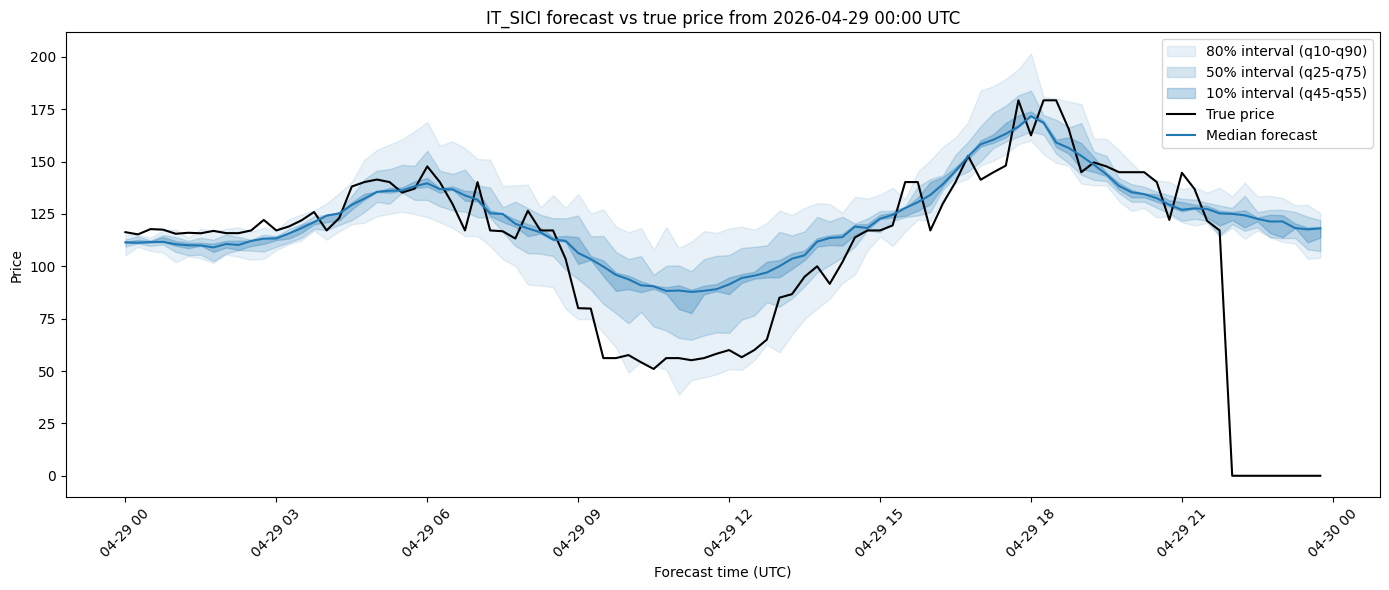

In [ ]:
quantiles =  [0.10, 0.25, 0.45, 0.50, 0.55, 0.75, 0.90]

forecast_result = normalize_and_forecast(
    loaded_data=loaded_data,
    phase2_model_path=phase2_model_path,
    forecast_target_country=forecast_target_country,
    forecast_graph_degree=forecast_graph_degree,
    adjacency_dict=adjacency_dict,
    input_countries=countries,
    features=features,
    lag_features=lag_features,
    lead_features=lead_features,
    label_column=label_column,
    x_scalers=x_scalers,
    y_scalers=y_scalers,
    quantiles=quantiles,
)
display(produce_testing_metrics(forecast_result, y_scalers)[['AQL', 'RMSE', 'MAE']])
display(forecast_result["forecast_df"].head())
fig, ax = visualize_forecast(forecast_result)
plt.show()

In [ ]:
#import netron
#netron.start(f"ckpt_place")